<a href="https://colab.research.google.com/github/adityaraghavan98/camm_hackathon/blob/k4my4r/patch-1/docs/day_4_11072025/CAMM_Hackathon_4_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#XRD Data from Dr Katherine Page

In [1]:
!gdown --fuzzy https://drive.google.com/file/d/1Zzknr5yjvzTgPCMY7PD4YjcRJoecBK8z/view?usp=sharing

Downloading...
From: https://drive.google.com/uc?id=1Zzknr5yjvzTgPCMY7PD4YjcRJoecBK8z
To: /content/Data for Hackathon.zip
100% 937k/937k [00:00<00:00, 13.3MB/s]


In [7]:
!unzip '/content/Data for Hackathon.zip'

Archive:  /content/Data for Hackathon.zip
   creating: Data for Hackathon/
   creating: Data for Hackathon/Cifs/
  inflating: Data for Hackathon/Cifs/Gadolinium Titanate Pyro.cif  
  inflating: Data for Hackathon/Cifs/Hybrid HE Ti Pyro.cif  
  inflating: Data for Hackathon/Info.txt  
   creating: Data for Hackathon/PrNdGdYbLu2 Ti2 O7/
  inflating: Data for Hackathon/PrNdGdYbLu2 Ti2 O7/PrNdGdYbLu_I11_175°C.xrdml  
  inflating: Data for Hackathon/PrNdGdYbLu2 Ti2 O7/PrNdGdYbLu_I14_225°C.xrdml  
  inflating: Data for Hackathon/PrNdGdYbLu2 Ti2 O7/PrNdGdYbLu_I17_275°C.xrdml  
  inflating: Data for Hackathon/PrNdGdYbLu2 Ti2 O7/PrNdGdYbLu_I20_325°C.xrdml  
  inflating: Data for Hackathon/PrNdGdYbLu2 Ti2 O7/PrNdGdYbLu_I23_375°C.xrdml  
  inflating: Data for Hackathon/PrNdGdYbLu2 Ti2 O7/PrNdGdYbLu_I26_425°C.xrdml  
  inflating: Data for Hackathon/PrNdGdYbLu2 Ti2 O7/PrNdGdYbLu_I29_475°C.xrdml  
  inflating: Data for Hackathon/PrNdGdYbLu2 Ti2 O7/PrNdGdYbLu_I2_25°C.xrdml  
  inflating: Data for Hac

In [14]:
import os, textwrap

BASE = "/content/Data for Hackathon"
for d in sorted(os.listdir(BASE)):
    p = os.path.join(BASE, d)
    mark = "📁" if os.path.isdir(p) else "📄"
    print(f"{mark} {d}")


📁 Cifs
📄 Info.txt
📁 PrNdGdYbLu2 Ti2 O7
📁 PrSmGdHoLu2 Ti2 O7
📁 SmEuGdTbDy2 Ti2 O7
📁 Standard Data


###  Accessing and Exploring the XRD Data

Each folder inside `/content/Data` contains XRD scans for a different material:

```
/content/Data
 ├── PrNdGdYbLu2 Ti2 O7/
 ├── PrSmGdHoLu2 Ti2 O7/
 ├── SmEuGdTbDy2 Ti2 O7/
 ├── Standard Data/
 └── Cifs/   ← structure models for fitting
```

#### 🧩 What you need to do

1. **Preview the data** – load and plot an XRD pattern from one of the sample folders.
2. **Compare patterns** – look at how the peaks shift between different samples.
3. **Use the CIFs** – later, you can use the `.cif` files in `/content/Data/Cifs` for model fitting (for example, in DARA).

#### 🧠 Steps

1. Run the next cell to define a **small function** that reads `.xrdml` files (the standard PANalytical format).
2. Change the folder name (for example, to `"SmEuGdTbDy2 Ti2 O7"`) and **run the next cell** to:

   * Plot one scan from that folder.
   * Optionally compare the first scan from all sample folders.

#### ⚙️ Notes

* The `Standard Data` folder is a **reference pattern** — use it to refine or fix your instrument parameters before fitting complex samples..
* Once you verify the data loads correctly, you can move to the **DARA refinement notebook** and use these same blocks to code there to load data in there.

In [26]:
from IPython.display import Markdown

path = "/content/Data for Hackathon/Info.txt"
with open(path) as f:
    content = f.read()

display(Markdown(f"### ℹ️ Dataset Information\n\n{content}"))


### ℹ️ Dataset Information

The raw X-Ray diffraction data are in the folders labelled by each sample name. Each file has the temperature that the measurement was taken at. For each a series of scans from 25-1175 C was taken at 50 C intervals.

A measured silicon standard is provided which can be used for making an instrument parameter file.

For Samples the compositions are as follows

Sm 2/5 Eu 2/5 Gd 2/5 Tb 2/5 Dy 2/5 Ti 2 O 7

Pr 2/5 Sm 2/5 Gd 2/5 Ho 2/5 Lu 2/5 Ti 2 O 7

Pr 2/5 Nd 2/5 Gd 2/5 Yb 2/5 Lu 2/5 Ti 2 O 7

For the cifs that were provided there is Gadolinium Titanate which can act as a baseline for adding elements and a Hybrid High Entropy Structure that has all the elements added into it as well as a degree of site inversion added in between the rare earth elements and the titanium.

In [21]:
# Minimal XRDML -> DataFrame
import xml.etree.ElementTree as ET, numpy as np, pandas as pd

def read_xrdml_df(path, scan_index=0):
    r = ET.parse(path).getroot(); ns = {"x": r.tag.split('}')[0].strip('{')}
    # prefer dataPoints blocks
    dp = r.find(".//x:dataPoints", ns) or r.find(".//x:scan//x:dataPoints", ns)
    if dp is None: raise ValueError("No dataPoints found")
    ints = (dp.findtext("x:intensities", namespaces=ns)
            or dp.findtext("x:counts", namespaces=ns) or "").strip()
    I = np.fromstring(ints, sep=' ')
    pos = dp.find("x:positions", ns)
    if pos is not None:
        s = pos.findtext("x:startPosition", namespaces=ns); e = pos.findtext("x:endPosition", namespaces=ns)
        if s and e: x = np.linspace(float(s), float(e), I.size)
        else:
            txt = (pos.text or "").strip(); x = np.fromstring(txt, sep=' ') if txt else None
    else:
        s = dp.findtext("x:startPosition", namespaces=ns); e = dp.findtext("x:endPosition", namespaces=ns)
        x = np.linspace(float(s), float(e), I.size) if s and e else None
    if x is None or I.size != x.size: raise ValueError("Could not reconstruct 2θ")
    return pd.DataFrame({"2theta_deg": x, "intensity": I})


/tmp/ipython-input-556778959.py:7: DeprecationWarning: Testing an element's truth value will always return True in future versions.  Use specific 'len(elem)' or 'elem is not None' test instead.
  dp = r.find(".//x:dataPoints", ns) or r.find(".//x:scan//x:dataPoints", ns)


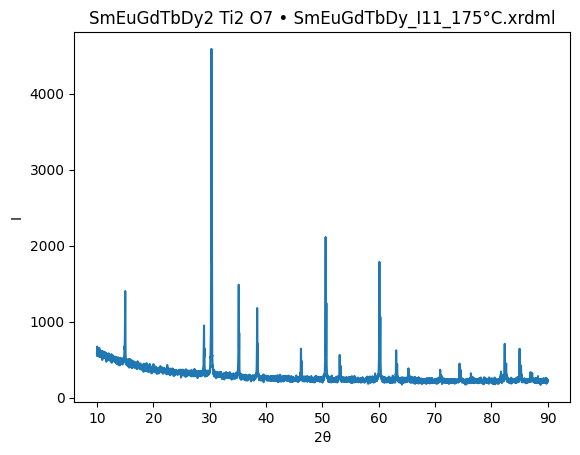

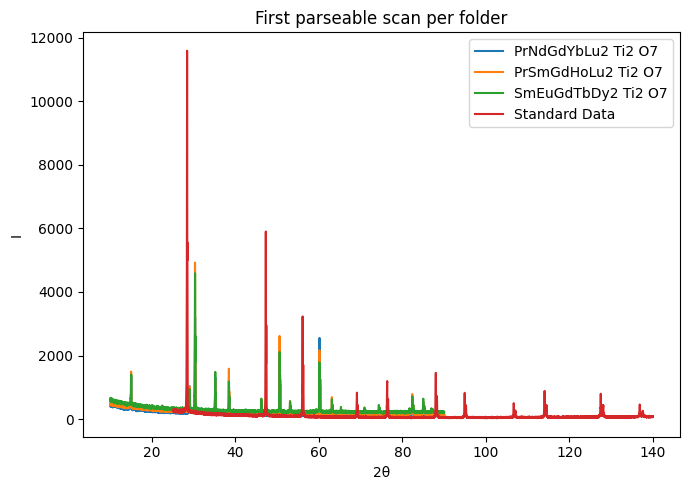

In [23]:
import os, matplotlib.pyplot as plt

BASE = "/content/Data for Hackathon"
SAMPLE_FOLDERS = [
    "PrNdGdYbLu2 Ti2 O7",
    "PrSmGdHoLu2 Ti2 O7",
    "SmEuGdTbDy2 Ti2 O7",
    "Standard Data",
]

# --- A) Preview ONE folder (change the name below) ---
FOLDER = "SmEuGdTbDy2 Ti2 O7"
p = os.path.join(BASE, FOLDER)
f = next((fn for fn in sorted(os.listdir(p)) if fn.lower().endswith(".xrdml")), None)
df = read_xrdml_df(os.path.join(p, f))
plt.plot(df["2theta_deg"], df["intensity"]); plt.xlabel("2θ"); plt.ylabel("I"); plt.title(f"{FOLDER} • {f}"); plt.show()

# --- B) Quick compare (first parseable file from each folder) ---
plt.figure(figsize=(7,5))
for name in SAMPLE_FOLDERS:
    q = os.path.join(BASE, name)
    files = [fn for fn in sorted(os.listdir(q)) if fn.lower().endswith(".xrdml")]
    for fn in files:
        try:
            df = read_xrdml_df(os.path.join(q, fn)); plt.plot(df["2theta_deg"], df["intensity"], label=name); break
        except Exception:
            continue
plt.xlabel("2θ"); plt.ylabel("I"); plt.title("First parseable scan per folder"); plt.legend(); plt.tight_layout(); plt.show()


# XRD data from Dr Claudia Rawn

In [27]:
!gdown --fuzzy https://drive.google.com/file/d/1RP9hezq8hVuTuPj-_Qy9zvbSDTSgHw7E/view?usp=sharing

Downloading...
From: https://drive.google.com/uc?id=1RP9hezq8hVuTuPj-_Qy9zvbSDTSgHw7E
To: /content/XRD Data for CAMM hackathon_Rawn.zip
100% 40.7k/40.7k [00:00<00:00, 1.43MB/s]


In [30]:
!unzip '/content/XRD Data for CAMM hackathon_Rawn.zip' -d /content/XRD_Hackathon_Rawn

Archive:  /content/XRD Data for CAMM hackathon_Rawn.zip
  inflating: /content/XRD_Hackathon_Rawn/(YPrNdHoTm)3Al5O12 PSE.xrdml  
  inflating: /content/XRD_Hackathon_Rawn/Al2O3 30024.cif  
  inflating: /content/XRD_Hackathon_Rawn/Tb3Al5O12 PSE.xrdml  
  inflating: /content/XRD_Hackathon_Rawn/Y3Al5O12 PSE.xrdml  
  inflating: /content/XRD_Hackathon_Rawn/Y3Al5O12 SSR.xrdml  
  inflating: /content/XRD_Hackathon_Rawn/Y3Al5O12 YAG 23848.cif  
  inflating: /content/XRD_Hackathon_Rawn/Y4Al2O9 YAM 63650 monoclinic P121c1.cif  
  inflating: /content/XRD_Hackathon_Rawn/YAlO3 YAP 27100 hexagonal P63mmc.cif  
  inflating: /content/XRD_Hackathon_Rawn/YAlO3 YAP 4115 orthorhombic Pnma.cif  
  inflating: /content/XRD_Hackathon_Rawn/ZrO2 89429.cif  


In [31]:
import os, textwrap

BASE = "/content/XRD_Hackathon_Rawn"
for d in sorted(os.listdir(BASE)):
    p = os.path.join(BASE, d)
    mark = "📁" if os.path.isdir(p) else "📄"
    print(f"{mark} {d}")


📄 (YPrNdHoTm)3Al5O12 PSE.xrdml
📄 Al2O3 30024.cif
📄 Tb3Al5O12 PSE.xrdml
📄 Y3Al5O12 PSE.xrdml
📄 Y3Al5O12 SSR.xrdml
📄 Y3Al5O12 YAG 23848.cif
📄 Y4Al2O9 YAM 63650 monoclinic P121c1.cif
📄 YAlO3 YAP 27100 hexagonal P63mmc.cif
📄 YAlO3 YAP 4115 orthorhombic Pnma.cif
📄 ZrO2 89429.cif


/tmp/ipython-input-556778959.py:7: DeprecationWarning: Testing an element's truth value will always return True in future versions.  Use specific 'len(elem)' or 'elem is not None' test instead.
  dp = r.find(".//x:dataPoints", ns) or r.find(".//x:scan//x:dataPoints", ns)


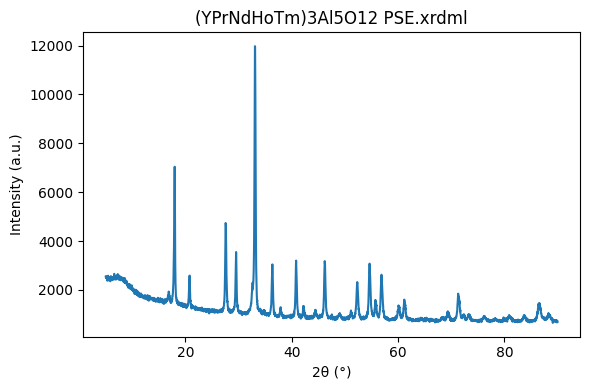

In [33]:
# --- Choose any .xrdml file from the folder ---
import matplotlib.pyplot as plt

file = "(YPrNdHoTm)3Al5O12 PSE.xrdml"  # 👈 change this
df = read_xrdml_df(os.path.join(BASE, file))

plt.figure(figsize=(6,4))
plt.plot(df["2theta_deg"], df["intensity"])
plt.xlabel("2θ (°)")
plt.ylabel("Intensity (a.u.)")
plt.title(file)
plt.tight_layout()
plt.show()


/tmp/ipython-input-556778959.py:7: DeprecationWarning: Testing an element's truth value will always return True in future versions.  Use specific 'len(elem)' or 'elem is not None' test instead.
  dp = r.find(".//x:dataPoints", ns) or r.find(".//x:scan//x:dataPoints", ns)


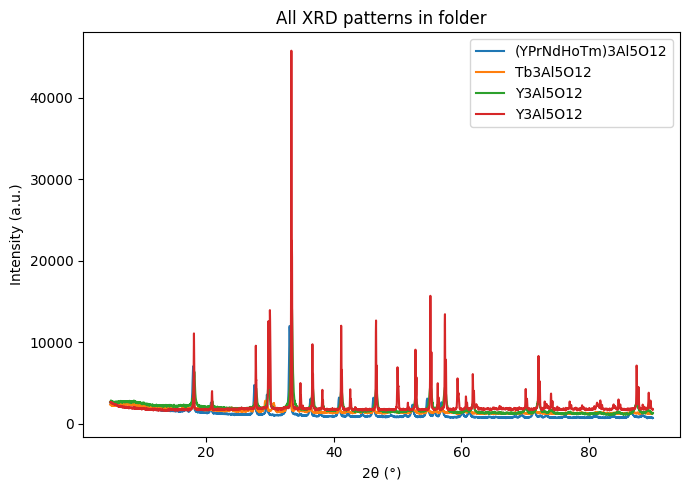

In [34]:
plt.figure(figsize=(7,5))
for f in sorted(os.listdir(BASE)):
    if f.lower().endswith(".xrdml"):
        try:
            df = read_xrdml_df(os.path.join(BASE, f))
            plt.plot(df["2theta_deg"], df["intensity"], label=f.split()[0])
        except Exception:
            continue
plt.xlabel("2θ (°)")
plt.ylabel("Intensity (a.u.)")
plt.legend()
plt.title("All XRD patterns in folder")
plt.tight_layout()
plt.show()


# CIF file info
To get some info on the .cif file, use the code below

In [36]:
file = "/content/XRD_Hackathon_Rawn/Al2O3 30024.cif"  # 👈 change this
with open(os.path.join(BASE, file)) as f:
    print(f.read()[:400], "...")



#(C) 2023 by FIZ Karlsruhe - Leibniz Institute for Information Infrastructure.  All rights reserved.
data_30024-ICSD
_database_code_ICSD 30024
_audit_creation_date 1980-01-01
_audit_update_record 2007-08-01
_chemical_name_common 'Aluminium oxide - Cr-doped'
_chemical_formula_structural 'Al2 O3'
_chemical_formula_sum 'Al2 O3'
_chemical_name_structure_type Corundum#Al2O3
_exptl_crystal_density_diff ...
